In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
print("Shape of dataset:", df.shape)
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nClass distribution:\n")
print(df["Class"].value_counts())

Shape of dataset: (13954, 31)

Data types:

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object

Missing values:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    1
Class 

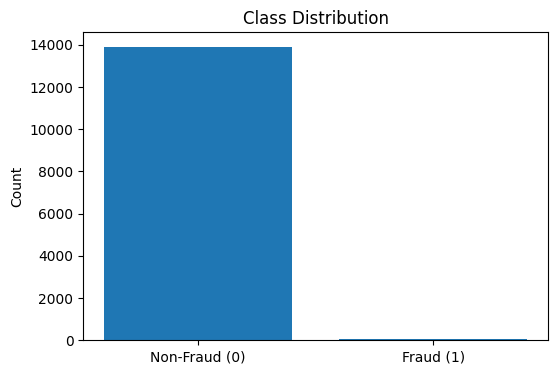

Fraud transactions percentage: 0.4013%


In [4]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Non-Fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"Fraud transactions percentage: {fraud_percentage:.4f}%")

In [5]:
scaler = StandardScaler()
df["Time"] = scaler.fit_transform(df[["Time"]])
df["Amount"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.307754,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.481995,0.0
1,-1.307754,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.344008,0.0
2,-1.307625,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.769600,0.0
3,-1.307625,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.335155,0.0
4,-1.307495,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.034335,0.0


In [7]:
df_cleaned = df.dropna(subset=['Class'])
X = df_cleaned.drop("Class", axis=1)
y = df_cleaned["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (11162, 30)
X_test shape: (2791, 30)
y_train distribution:
 Class
0.0    11117
1.0       45
Name: count, dtype: int64
y_test distribution:
 Class
0.0    2780
1.0      11
Name: count, dtype: int64


In [8]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-Score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return [name, acc, prec, rec, f1]

In [9]:
model_original = LogisticRegression(max_iter=1000, random_state=42)
results = []

result_original = evaluate_model(
    "Logistic Regression - Original Unbalanced Data",
    model_original,
    X_train, y_train,
    X_test, y_test
)

results.append(result_original)


Logistic Regression - Original Unbalanced Data
----------------------------------------
Accuracy : 0.9989
Precision: 0.9
Recall   : 0.8182
F1-Score : 0.8571

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2780
         1.0       0.90      0.82      0.86        11

    accuracy                           1.00      2791
   macro avg       0.95      0.91      0.93      2791
weighted avg       1.00      1.00      1.00      2791

Confusion Matrix:
 [[2779    1]
 [   2    9]]


In [10]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Before Oversampling:\n", y_train.value_counts())
print("\nAfter Oversampling:\n", y_train_ros.value_counts())

Before Oversampling:
 Class
0.0    11117
1.0       45
Name: count, dtype: int64

After Oversampling:
 Class
0.0    11117
1.0    11117
Name: count, dtype: int64


In [11]:
model_ros = LogisticRegression(max_iter=1000, random_state=42)

result_ros = evaluate_model(
    "Logistic Regression - Random Oversampling",
    model_ros,
    X_train_ros, y_train_ros,
    X_test, y_test
)

results.append(result_ros)


Logistic Regression - Random Oversampling
----------------------------------------
Accuracy : 0.9925
Precision: 0.3333
Recall   : 0.9091
F1-Score : 0.4878

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2780
         1.0       0.33      0.91      0.49        11

    accuracy                           0.99      2791
   macro avg       0.67      0.95      0.74      2791
weighted avg       1.00      0.99      0.99      2791

Confusion Matrix:
 [[2760   20]
 [   1   10]]


In [12]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Before Undersampling:\n", y_train.value_counts())
print("\nAfter Undersampling:\n", y_train_rus.value_counts())

Before Undersampling:
 Class
0.0    11117
1.0       45
Name: count, dtype: int64

After Undersampling:
 Class
0.0    45
1.0    45
Name: count, dtype: int64


In [13]:
model_rus = LogisticRegression(max_iter=1000, random_state=42)

result_rus = evaluate_model(
    "Logistic Regression - Random Undersampling",
    model_rus,
    X_train_rus, y_train_rus,
    X_test, y_test
)

results.append(result_rus)


Logistic Regression - Random Undersampling
----------------------------------------
Accuracy : 0.9832
Precision: 0.1786
Recall   : 0.9091
F1-Score : 0.2985

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      2780
         1.0       0.18      0.91      0.30        11

    accuracy                           0.98      2791
   macro avg       0.59      0.95      0.64      2791
weighted avg       1.00      0.98      0.99      2791

Confusion Matrix:
 [[2734   46]
 [   1   10]]


In [14]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Class
0.0    11117
1.0       45
Name: count, dtype: int64

After SMOTE:
 Class
0.0    11117
1.0    11117
Name: count, dtype: int64


In [15]:
model_smote = LogisticRegression(max_iter=1000, random_state=42)

result_smote = evaluate_model(
    "Logistic Regression - SMOTE",
    model_smote,
    X_train_smote, y_train_smote,
    X_test, y_test
)

results.append(result_smote)


Logistic Regression - SMOTE
----------------------------------------
Accuracy : 0.9936
Precision: 0.3704
Recall   : 0.9091
F1-Score : 0.5263

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2780
         1.0       0.37      0.91      0.53        11

    accuracy                           0.99      2791
   macro avg       0.69      0.95      0.76      2791
weighted avg       1.00      0.99      0.99      2791

Confusion Matrix:
 [[2763   17]
 [   1   10]]


In [17]:
results_df = pd.DataFrame(results, columns=["Method", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df

,Method,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression - Original Unbalanced Data,0.998925,0.900000,0.818182,0.857143
1,Logistic Regression - Random Oversampling,0.992476,0.333333,0.909091,0.487805
2,Logistic Regression - Random Undersampling,0.983160,0.178571,0.909091,0.298507
3,Logistic Regression - SMOTE,0.993551,0.370370,0.909091,0.526316


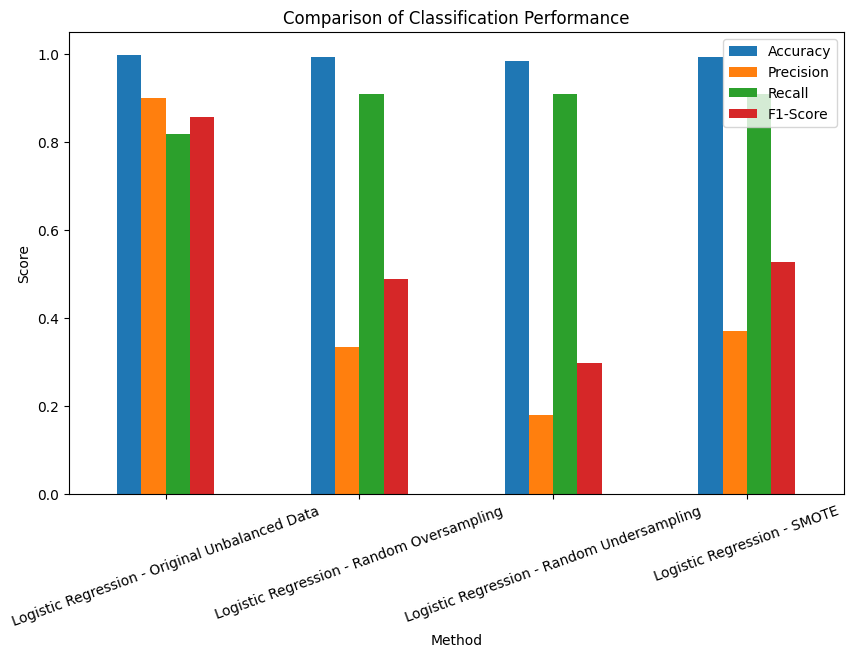

In [18]:
results_df.set_index("Method")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Classification Performance")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.show()

In [19]:
print("Conclusion:")
print("1. The dataset is highly imbalanced, with very few fraud cases compared to non-fraud cases.")
print("2. Training on the original data may give high accuracy, but accuracy alone is misleading in imbalanced datasets.")
print("3. Balancing techniques such as Random Oversampling, Random Undersampling, and SMOTE help improve fraud detection.")
print("4. Recall and F1-score are more important than accuracy in this problem because detecting fraud cases is the main goal.")
print("5. SMOTE often gives a better balance between detecting fraud cases and keeping good overall performance.")

Conclusion:
1. The dataset is highly imbalanced, with very few fraud cases compared to non-fraud cases.
2. Training on the original data may give high accuracy, but accuracy alone is misleading in imbalanced datasets.
3. Balancing techniques such as Random Oversampling, Random Undersampling, and SMOTE help improve fraud detection.
4. Recall and F1-score are more important than accuracy in this problem because detecting fraud cases is the main goal.
5. SMOTE often gives a better balance between detecting fraud cases and keeping good overall performance.
